# Atividade Ciência de dados 4

- Fernando Júdice
- Ilanna Haimenis


## Descrição

Esta atividade irá utilizar um dataset de características de vinho.
O objetivo será classificar o vinho como bom ou ruim. Um vinho bom será considerado aquele com nota igual ou superior a 7.

### 1 - Importar e preparar os dados

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.
Path to dataset files: /kaggle/input/red-wine-quality-cortez-et-al-2009


In [3]:
import pandas as pd
import os

csv_file_path = os.path.join(path, 'winequality-red.csv')
df = pd.read_csv(csv_file_path)
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Passo 1 - Escolher coluna para classificação

bins = [0, 7, 10]
labels = ['not good', 'good']
df['quality_category'] = pd.cut(df['quality'], bins=bins, labels=labels, right=False)
display(df['quality_category'].value_counts())
display(df.head())

,count
quality_category,
not good,1382
good,217


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_category
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,not good
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,not good
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,not good
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,not good
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,not good


In [5]:
# Verificar valores nulos e vazios

missing_values = df.isnull().sum()
display(missing_values)

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [9]:
# Transformar categoria em um dado numérico

quality_mapping = {'not good': 0, 'good': 1}
df['quality_numeric'] = df['quality_category'].map(quality_mapping)
display(df['quality_numeric'].value_counts())
display(df.head())

,count
quality_numeric,
0,1382
1,217


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_category,quality_numeric
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,not good,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,not good,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,not good,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,not good,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,not good,0


### 2 - Divisão em dataset de treino, validação e teste:

treino: 70%
validação: 20%
teste: 10%

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(['quality', 'quality_category', 'quality_numeric'], axis=1)
y = df['quality_numeric']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp)

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

print("\nTraining set quality distribution:")
display(y_train.value_counts(normalize=True))
print("\nValidation set quality distribution:")
display(y_val.value_counts(normalize=True))
print("\nTest set quality distribution:")
display(y_test.value_counts(normalize=True))

Training set shape: (1119, 11) (1119,)
Validation set shape: (320, 11) (320,)
Test set shape: (160, 11) (160,)

Training set quality distribution:


,proportion
quality_numeric,
0,0.864164
1,0.135836



Validation set quality distribution:


,proportion
quality_numeric,
0,0.865625
1,0.134375



Test set quality distribution:


,proportion
quality_numeric,
0,0.8625
1,0.1375


In [26]:
# Balancear o set de treino utilizando downsampling

import pandas as pd
from sklearn.utils import resample

train_df = X_train.copy()
train_df['quality_numeric'] = y_train

class_counts = train_df['quality_numeric'].value_counts().sort_index()

df_class_0 = train_df[train_df['quality_numeric'] == 0]
df_class_1 = train_df[train_df['quality_numeric'] == 1]

minority_count = class_counts[1]
df_class_0_downsampled = resample(df_class_0,
                                  replace=False,
                                  n_samples=minority_count,
                                  random_state=42)

downsampled_train_df = pd.concat([df_class_0_downsampled, df_class_1])

X_train_resampled = downsampled_train_df.drop('quality_numeric', axis=1)
y_train_resampled = downsampled_train_df['quality_numeric']

print("Original training set quality distribution:")
display(y_train.value_counts().sort_index())

print("\nResampled training set quality distribution (Downsampling):")
display(y_train_resampled.value_counts().sort_index())

Original training set quality distribution:


,count
quality_numeric,
0,967
1,152



Resampled training set quality distribution (Downsampling):


,count
quality_numeric,
0,152
1,152


### 3 - treinar modelo

Modelos utilizados:
- KNN
- Random Forest

In [13]:
%pip install mlflow optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 8.9 MB/s eta 0:00:00


### 3.1 KNN Classifier

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import mlflow
import optuna
import pandas as pd
from mlflow.models import infer_signature

# Define the pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier())
])

# Define the objective function for Optuna
def objective(trial):
    with mlflow.start_run(nested=True): # Use nested runs for Optuna trials
        # Define hyperparameters to tune
        n_neighbors = trial.suggest_int('knn__n_neighbors', 3, 15)
        weights = trial.suggest_categorical('knn__weights', ['uniform', 'distance'])

        mlflow.log_param("n_neighbors", n_neighbors)
        mlflow.log_param("weights", weights)

        pipeline.set_params(knn__n_neighbors=n_neighbors, knn__weights=weights)

        pipeline.fit(X_train_resampled, y_train_resampled)

        y_pred = pipeline.predict(X_val)

        accuracy = accuracy_score(y_val, y_pred)

        mlflow.log_metric("accuracy", accuracy)

        report = classification_report(y_val, y_pred, output_dict=True, zero_division=0)

        for label, metrics in report.items():
            if label in ['0', '1']:
                mlflow.log_metric(f"precision_{label}", metrics['precision'])
                mlflow.log_metric(f"recall_{label}", metrics['recall'])
                mlflow.log_metric(f"f1-score_{label}", metrics['f1-score'])
            elif label in ['macro avg', 'weighted avg']:
                 for metric_name, metric_value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric_name}", metric_value)

        return -accuracy

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20) # Run 20 trials (you can adjust this)

print("\nBest trial:")
trial = study.best_trial

print(f"  Value: {trial.value:.4f} (Negative Accuracy)")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-09-26 23:26:43,807] A new study created in memory with name: no-name-af0051b0-45a1-4c56-a9fc-7300630c4b11
[I 2025-09-26 23:26:43,931] Trial 0 finished with value: -0.825 and parameters: {'knn__n_neighbors': 15, 'knn__weights': 'distance'}. Best is trial 0 with value: -0.825.
[I 2025-09-26 23:26:44,044] Trial 1 finished with value: -0.825 and parameters: {'knn__n_neighbors': 5, 'knn__weights': 'distance'}. Best is trial 0 with value: -0.825.
[I 2025-09-26 23:26:44,155] Trial 2 finished with value: -0.821875 and parameters: {'knn__n_neighbors': 5, 'knn__weights': 'uniform'}. Best is trial 0 with value: -0.825.
[I 2025-09-26 23:26:44,267] Trial 3 finished with value: -0.7875 and parameters: {'knn__n_neighbors': 3, 'knn__weights': 'distance'}. Best is trial 0 with value: -0.825.
[I 2025-09-26 23:26:44,377] Trial 4 finished with value: -0.825 and parameters: {'knn__n_neighbors': 15, 'knn__weights': 'distance'}. Best is trial 0 with value: -0.825.
[I 2025-09-26 23:26:44,516] Trial 5 


Best trial:
  Value: -0.8531 (Negative Accuracy)
  Params: 
    knn__n_neighbors: 6
    knn__weights: uniform


### 3.2 Random Forest Classifier

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler # Changed to MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import mlflow
import optuna
import pandas as pd
from mlflow.models import infer_signature

pipeline_rf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

def objective_rf(trial):
    with mlflow.start_run(nested=True):
        n_estimators = trial.suggest_int('rf__n_estimators', 50, 200)
        max_depth = trial.suggest_categorical('rf__max_depth', [None, 10, 20])
        min_samples_split = trial.suggest_int('rf__min_samples_split', 2, 10)

        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)
        mlflow.log_param("min_samples_split", min_samples_split)

        pipeline_rf.set_params(rf__n_estimators=n_estimators, rf__max_depth=max_depth, rf__min_samples_split=min_samples_split)

        pipeline_rf.fit(X_train_resampled, y_train_resampled)

        y_pred_rf = pipeline_rf.predict(X_val)

        accuracy_rf = accuracy_score(y_val, y_pred_rf)

        mlflow.log_metric("accuracy", accuracy_rf)

        report_rf = classification_report(y_val, y_pred_rf, output_dict=True, zero_division=0)

        for label, metrics in report_rf.items():
            if label in ['0', '1']: # Assuming labels are '0' and '1'
                mlflow.log_metric(f"precision_{label}", metrics['precision'])
                mlflow.log_metric(f"recall_{label}", metrics['recall'])
                mlflow.log_metric(f"f1-score_{label}", metrics['f1-score'])
            elif label in ['macro avg', 'weighted avg']:
                 for metric_name, metric_value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric_name}", metric_value)

        return -accuracy_rf

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=20)

print("\nBest trial for Random Forest:")
trial_rf = study_rf.best_trial

print(f"  Value: {trial_rf.value:.4f} (Negative Accuracy)")
print("  Params: ")
for key, value in trial_rf.params.items():
    print(f"    {key}: {value}")

[I 2025-09-26 23:27:32,860] A new study created in memory with name: no-name-729ac5c5-ca97-4309-93d6-0af7a2b327b5
[I 2025-09-26 23:27:33,366] Trial 0 finished with value: -0.834375 and parameters: {'rf__n_estimators': 190, 'rf__max_depth': 10, 'rf__min_samples_split': 8}. Best is trial 0 with value: -0.834375.
[I 2025-09-26 23:27:33,707] Trial 1 finished with value: -0.828125 and parameters: {'rf__n_estimators': 113, 'rf__max_depth': None, 'rf__min_samples_split': 5}. Best is trial 0 with value: -0.834375.
[I 2025-09-26 23:27:34,022] Trial 2 finished with value: -0.821875 and parameters: {'rf__n_estimators': 101, 'rf__max_depth': 20, 'rf__min_samples_split': 2}. Best is trial 0 with value: -0.834375.
[I 2025-09-26 23:27:34,427] Trial 3 finished with value: -0.853125 and parameters: {'rf__n_estimators': 136, 'rf__max_depth': None, 'rf__min_samples_split': 3}. Best is trial 3 with value: -0.853125.
[I 2025-09-26 23:27:34,668] Trial 4 finished with value: -0.828125 and parameters: {'rf__n


Best trial for Random Forest:
  Value: -0.8531 (Negative Accuracy)
  Params: 
    rf__n_estimators: 136
    rf__max_depth: None
    rf__min_samples_split: 3


### 3.3 - Gerar melhor modelo e verificar com test set

Baseado na busca de hiperparâmetros, o melhor modelo foi knn com  
- knn__n_neighbors: 6
- knn__weights: uniform

In [29]:
import mlflow
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler


knn_params = {
    'n_neighbors': 6,
    'weights': 'uniform'
}

knn_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(**knn_params))
])

knn_pipeline.fit(X_train, y_train)

print("KNN model training complete.")

y_test_pred_knn = knn_pipeline.predict(X_test)

test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
print(f"\nTest Set Accuracy (Trained KNN Model): {test_accuracy_knn:.4f}")

test_report_knn = classification_report(y_test, y_test_pred_knn, zero_division=0)
print("\nTest Set Classification Report (Trained KNN Model):")
print(test_report_knn)

best_pipeline = knn_pipeline
y_test_pred = y_test_pred_knn

Training a KNN model with hyperparameters: {'n_neighbors': 6, 'weights': 'uniform'}
KNN model training complete.

Test Set Accuracy (Trained KNN Model): 0.8875

Test Set Classification Report (Trained KNN Model):
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       138
           1       0.75      0.27      0.40        22

    accuracy                           0.89       160
   macro avg       0.82      0.63      0.67       160
weighted avg       0.87      0.89      0.86       160



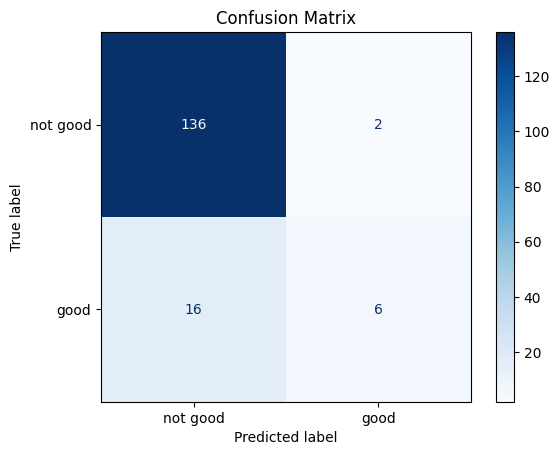

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_test_pred = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not good', 'good']) # Assuming labels based on mapping

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

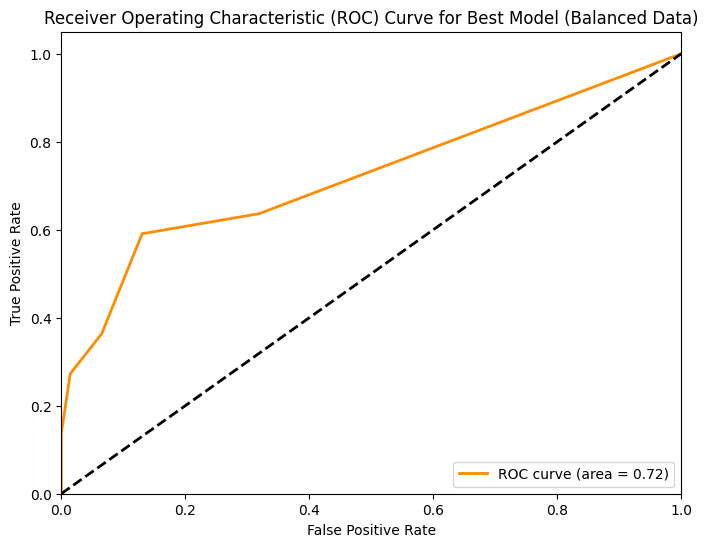

In [31]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

y_test_prob_positive_class = best_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_test_prob_positive_class, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Best Model (Balanced Data)')
plt.legend(loc="lower right")
plt.show()

### 3.4 Análise e insights

Percebemos que, apesar da acurácia relativamente elevada, o modelo não detecta bem vinhos da categoria "bom". O valor de recall foi de 0.27, indicando uma grande incidência de falsos negativos.

Este comportamente é possivelmente derivado do downsampling realizado para o balanceamento das classes. Uma grande quantidade de amostras foi descartada, reduzindo consideravelmente o espaço amostral. Dessa forma, um ponto de possível melhoria a ser explorado é realizar o balanceamento utilizando uma técnica de upsampling.

## 4.1 - Smote resampling para balancear as categorias

In [32]:
## Smote resampling

import pandas as pd
from imblearn.over_sampling import SMOTE # Import SMOTE
from collections import Counter # Import Counter

# Assuming X_train and y_train are already defined and contain only classes 0 and 1

print("Original training set shape:", X_train.shape)
print("Original training set quality distribution:", Counter(y_train))

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled_smote, y_train_resampled_smote = smote.fit_resample(X_train, y_train)

print("\nResampled training set shape (SMOTE):", X_train_resampled_smote.shape)
print("Resampled training set quality distribution (SMOTE):", Counter(y_train_resampled_smote))

# Make the SMOTE resampled data available for subsequent cells
X_train_resampled = X_train_resampled_smote
y_train_resampled = y_train_resampled_smote

Original training set shape: (1119, 11)
Original training set quality distribution: Counter({0: 967, 1: 152})

Resampled training set shape (SMOTE): (1934, 11)
Resampled training set quality distribution (SMOTE): Counter({0: 967, 1: 967})


### 4.2 KNN Classifier

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import mlflow
import optuna
import pandas as pd
from mlflow.models import infer_signature

# Define the pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier())
])

# Define the objective function for Optuna
def objective(trial):
    with mlflow.start_run(nested=True): # Use nested runs for Optuna trials
        # Define hyperparameters to tune
        n_neighbors = trial.suggest_int('knn__n_neighbors', 3, 15)
        weights = trial.suggest_categorical('knn__weights', ['uniform', 'distance'])

        mlflow.log_param("n_neighbors", n_neighbors)
        mlflow.log_param("weights", weights)

        pipeline.set_params(knn__n_neighbors=n_neighbors, knn__weights=weights)

        pipeline.fit(X_train_resampled, y_train_resampled)

        y_pred = pipeline.predict(X_val)

        accuracy = accuracy_score(y_val, y_pred)

        mlflow.log_metric("accuracy", accuracy)

        report = classification_report(y_val, y_pred, output_dict=True, zero_division=0)

        for label, metrics in report.items():
            if label in ['0', '1']:
                mlflow.log_metric(f"precision_{label}", metrics['precision'])
                mlflow.log_metric(f"recall_{label}", metrics['recall'])
                mlflow.log_metric(f"f1-score_{label}", metrics['f1-score'])
            elif label in ['macro avg', 'weighted avg']:
                 for metric_name, metric_value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric_name}", metric_value)

        return -accuracy

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20) # Run 20 trials (you can adjust this)

print("\nBest trial:")
trial = study.best_trial

print(f"  Value: {trial.value:.4f} (Negative Accuracy)")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-09-26 23:31:26,534] A new study created in memory with name: no-name-c9b5cddc-eede-4a35-9812-b7ca565ef75f
[I 2025-09-26 23:31:26,664] Trial 0 finished with value: -0.80625 and parameters: {'knn__n_neighbors': 13, 'knn__weights': 'uniform'}. Best is trial 0 with value: -0.80625.
[I 2025-09-26 23:31:26,780] Trial 1 finished with value: -0.846875 and parameters: {'knn__n_neighbors': 8, 'knn__weights': 'uniform'}. Best is trial 1 with value: -0.846875.
[I 2025-09-26 23:31:26,904] Trial 2 finished with value: -0.81875 and parameters: {'knn__n_neighbors': 11, 'knn__weights': 'uniform'}. Best is trial 1 with value: -0.846875.
[I 2025-09-26 23:31:27,021] Trial 3 finished with value: -0.846875 and parameters: {'knn__n_neighbors': 8, 'knn__weights': 'uniform'}. Best is trial 1 with value: -0.846875.
[I 2025-09-26 23:31:27,144] Trial 4 finished with value: -0.853125 and parameters: {'knn__n_neighbors': 12, 'knn__weights': 'distance'}. Best is trial 4 with value: -0.853125.
[I 2025-09-26 2


Best trial:
  Value: -0.8906 (Negative Accuracy)
  Params: 
    knn__n_neighbors: 4
    knn__weights: distance


### 4.3 Random Forest Classifier

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler # Changed to MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import mlflow
import optuna
import pandas as pd
from mlflow.models import infer_signature

pipeline_rf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

def objective_rf(trial):
    with mlflow.start_run(nested=True):
        n_estimators = trial.suggest_int('rf__n_estimators', 50, 200)
        max_depth = trial.suggest_categorical('rf__max_depth', [None, 10, 20])
        min_samples_split = trial.suggest_int('rf__min_samples_split', 2, 10)

        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)
        mlflow.log_param("min_samples_split", min_samples_split)

        pipeline_rf.set_params(rf__n_estimators=n_estimators, rf__max_depth=max_depth, rf__min_samples_split=min_samples_split)

        pipeline_rf.fit(X_train_resampled, y_train_resampled)

        y_pred_rf = pipeline_rf.predict(X_val)

        accuracy_rf = accuracy_score(y_val, y_pred_rf)

        mlflow.log_metric("accuracy", accuracy_rf)

        report_rf = classification_report(y_val, y_pred_rf, output_dict=True, zero_division=0)

        for label, metrics in report_rf.items():
            if label in ['0', '1']: # Assuming labels are '0' and '1'
                mlflow.log_metric(f"precision_{label}", metrics['precision'])
                mlflow.log_metric(f"recall_{label}", metrics['recall'])
                mlflow.log_metric(f"f1-score_{label}", metrics['f1-score'])
            elif label in ['macro avg', 'weighted avg']:
                 for metric_name, metric_value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric_name}", metric_value)

        return -accuracy_rf

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=20)

print("\nBest trial for Random Forest:")
trial_rf = study_rf.best_trial

print(f"  Value: {trial_rf.value:.4f} (Negative Accuracy)")
print("  Params: ")
for key, value in trial_rf.params.items():
    print(f"    {key}: {value}")

[I 2025-09-26 23:31:47,497] A new study created in memory with name: no-name-386ed395-5979-4eac-b3b7-b8da51acc595
[I 2025-09-26 23:31:48,197] Trial 0 finished with value: -0.903125 and parameters: {'rf__n_estimators': 77, 'rf__max_depth': 20, 'rf__min_samples_split': 2}. Best is trial 0 with value: -0.903125.
[I 2025-09-26 23:31:48,818] Trial 1 finished with value: -0.909375 and parameters: {'rf__n_estimators': 70, 'rf__max_depth': 20, 'rf__min_samples_split': 3}. Best is trial 1 with value: -0.909375.
[I 2025-09-26 23:31:50,252] Trial 2 finished with value: -0.909375 and parameters: {'rf__n_estimators': 175, 'rf__max_depth': 20, 'rf__min_samples_split': 2}. Best is trial 1 with value: -0.909375.
[I 2025-09-26 23:31:51,041] Trial 3 finished with value: -0.90625 and parameters: {'rf__n_estimators': 89, 'rf__max_depth': None, 'rf__min_samples_split': 2}. Best is trial 1 with value: -0.909375.
[I 2025-09-26 23:31:51,811] Trial 4 finished with value: -0.871875 and parameters: {'rf__n_estim


Best trial for Random Forest:
  Value: -0.9187 (Negative Accuracy)
  Params: 
    rf__n_estimators: 132
    rf__max_depth: 20
    rf__min_samples_split: 7


### 4.4 - Gerar melhor modelo e avaliar com o set de test

Baseado na busca de hiperparâmetros, o melhor modelo foi random forest com  
- rf__n_estimators: 132
- rf__max_depth: 20
- rf__min_samples_split: 7

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Define the hyperparameters for the Random Forest model
rf_params = {
    'n_estimators': 132,
    'max_depth': 20,
    'min_samples_split': 7,
    'random_state': 42 # Keep the random state for reproducibility
}

print(f"Training a Random Forest model with hyperparameters: {rf_params}")

# Create a pipeline with the scaler and the Random Forest model
# Assuming MinMaxScaler was used in your previous steps
rf_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('rf', RandomForestClassifier(**rf_params))
])

# Train the pipeline on the resampled training data
# Using the latest resampled data (SMOTE)
rf_pipeline.fit(X_train_resampled, y_train_resampled)

print("Random Forest model training complete.")

# Evaluate the trained Random Forest model on the test set
y_test_pred_rf = rf_pipeline.predict(X_test)

# Calculate and display test accuracy
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"\nTest Set Accuracy (Trained Random Forest Model): {test_accuracy_rf:.4f}")

# Display classification report for the test set
test_report_rf = classification_report(y_test, y_test_pred_rf, zero_division=0)
print("\nTest Set Classification Report (Trained Random Forest Model):")
print(test_report_rf)

# Make the trained pipeline and predictions available for subsequent cells
best_pipeline_resampled = rf_pipeline
y_test_pred_resampled = y_test_pred_rf

Training a Random Forest model with hyperparameters: {'n_estimators': 132, 'max_depth': 20, 'min_samples_split': 7, 'random_state': 42}
Random Forest model training complete.

Test Set Accuracy (Trained Random Forest Model): 0.9062

Test Set Classification Report (Trained Random Forest Model):
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       138
           1       0.65      0.68      0.67        22

    accuracy                           0.91       160
   macro avg       0.80      0.81      0.81       160
weighted avg       0.91      0.91      0.91       160



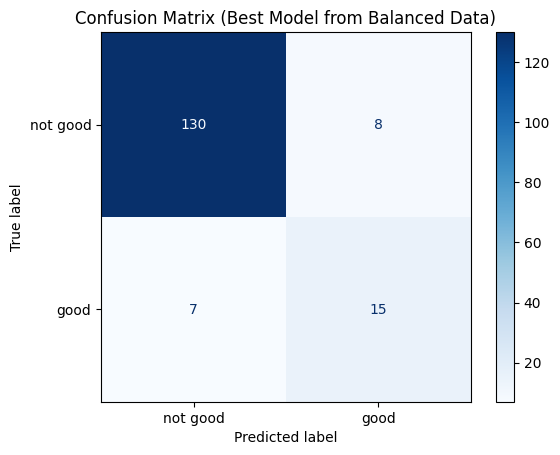

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the test set
y_test_pred = best_pipeline_resampled.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not good', 'good']) # Assuming labels based on mapping

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Best Model from Balanced Data)')
plt.show()

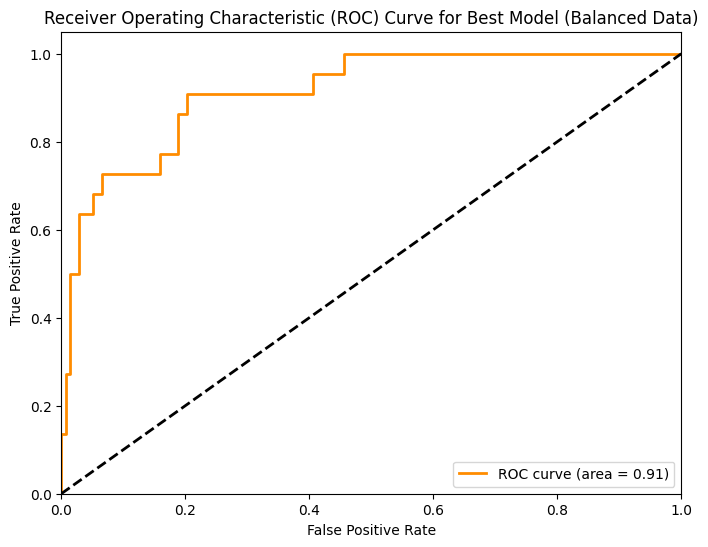

In [38]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

# Assuming best_pipeline_balanced, X_test, and y_test are defined and contain only classes 0 and 1

# Get predicted probabilities for the positive class (assuming 'good' is class 1)
y_test_prob_positive_class = best_pipeline_resampled.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area
# Assuming 'good' is the positive class (label 1)
fpr, tpr, _ = roc_curve(y_test, y_test_prob_positive_class, pos_label=1)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Best Model (Balanced Data)')
plt.legend(loc="lower right")
plt.show()

### 4.4 - Conclusão e insights

Observamos que enquanto a acurácia se manteve similar, o comportamento relativo a classe "bom" foi bastante diferente. O valor de recall subiu para 0.68, representando uma redução considerável do número de falsos negativos. Em contrapartida, houve uma leve perda de precisão, descendo esta para 0.65.

A escolha entre a abordagem irá derivar da necessidade do problema. Em um cenário, por exemplo, no qual a vinícula deseje criar uma linha de produtos de alta qualidade, seria mais interessante um modelo que reduza a quantidade de falsos positivos (alta precisão). Assim, teria-se a confiança de que os vinhos selecionados pelo modelo seriam de alta qualidade.

Em contrapartida, em uma abordagem que busque maximizar o aproveitamento da safra, pode-se querer maximizar o número de vinhos "bons" produzidos. Assim, uma solução que minimize falsos negativos e gere o maior lote de vinhos "bons" seria mais indicada